In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [39]:
notional_eur = 1000000
strike = 4.4439
T_years = 3
dt = 1 / 12
n_steps = int(T_years / dt)
n_simulations = 10000

S0 = 4.2166
r_eur = 0.0200
r_pln = 0.0375

In [40]:
try:
    eurpln_df = pd.read_csv("eurpln_d.csv", parse_dates=["Data"])
    eurpln_df = eurpln_df[(eurpln_df["Data"] >= "2024-01-01") & (eurpln_df["Data"] <= "2025-12-31")]
    eurpln_df = eurpln_df.sort_values("Data")

    close_series = eurpln_df["Zamkniecie"]
    log_returns = np.log(close_series / close_series.shift(1)).dropna()
    sigma_daily = log_returns.std()
    sigma_annual = float(sigma_daily * np.sqrt(252))
    print(f"Obliczona z danych ze Stooq zmienność roczna (sigma): {sigma_annual:.2%}\n")
except Exception as e:
    sigma_annual = 0.0570
    print(f"BŁĄD POBIERANIA DANYCH Z PLIKU! Szczegóły błędu: {e}")
    print(f"Użyto domyślnej zmienności (sigma): {sigma_annual:.2%}\n")


np.random.seed(42)
S_paths = np.zeros((n_steps + 1, n_simulations))
S_paths[0] = S0
mu = r_pln - r_eur

for i in range(1, n_steps + 1):
    Z = np.random.standard_normal(n_simulations)
    S_paths[i] = S_paths[i-1] * np.exp((mu - 0.5 * sigma_annual**2) * dt + sigma_annual * np.sqrt(dt) * Z)

time_grid = np.linspace(0, T_years, n_steps + 1)
tau = T_years - time_grid
df_eur = np.exp(-r_eur * tau).reshape(-1, 1)
df_pln = np.exp(-r_pln * tau).reshape(-1, 1)

MtM_paths = (notional_eur * S_paths * df_eur) - (notional_eur * strike * df_pln)
exposure = np.maximum(0, MtM_paths)
EE_profile = np.mean(exposure, axis=1)
PFE_95 = np.percentile(exposure, 95, axis=1)

Obliczona z danych ze Stooq zmienność roczna (sigma): 4.38%



In [41]:
print(" SANITY CHECKS" )
V0_analytical = notional_eur * (S0 * np.exp(-r_eur * T_years) - strike * np.exp(-r_pln * T_years))
print(f"Fair Value w t=0 (analitycznie): {V0_analytical:,.2f} PLN")
print(f"Średnia symulacji MtM w t=0: {np.mean(MtM_paths[0]):,.2f} PLN")
VT_payoff_analytical = notional_eur * (S_paths[-1, 0] - strike)
print(f"Wypłata na ścieżce 0 w t=T (przy DF=1): {VT_payoff_analytical:,.2f} PLN")
print(f"MtM na ścieżce 0 w t=T (symulacja): {MtM_paths[-1, 0]:,.2f} PLN\n")

 SANITY CHECKS
Fair Value w t=0 (analitycznie): -12.92 PLN
Średnia symulacji MtM w t=0: -12.92 PLN
Wypłata na ścieżce 0 w t=T (przy DF=1): 295,978.59 PLN
MtM na ścieżce 0 w t=T (symulacja): 295,978.59 PLN



Numeryczne maksimum EE: t = 3.0 lat, wartość = 133,394 PLN


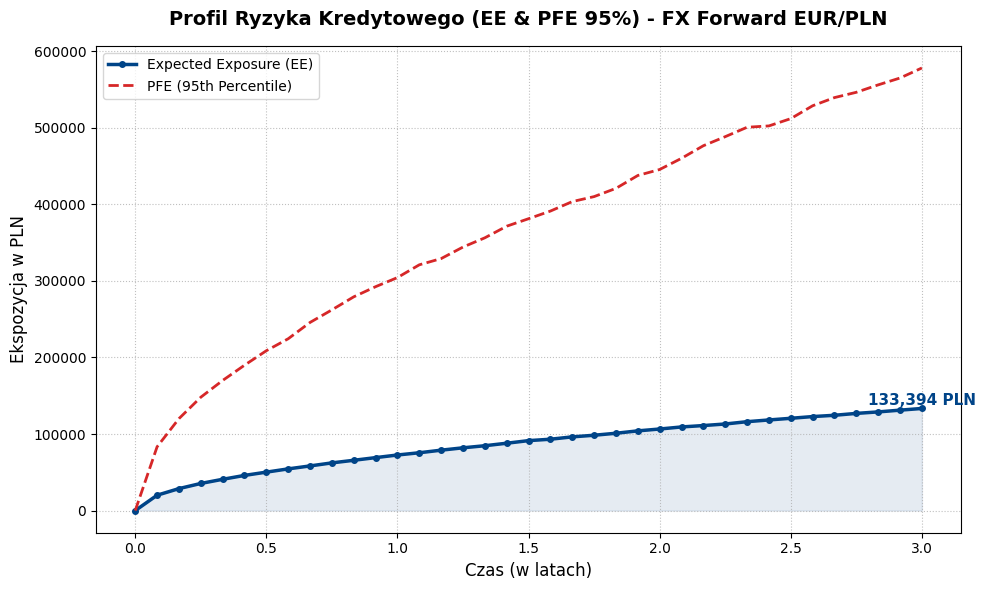

In [37]:
peak_idx = np.argmax(EE_profile)
print(f"Numeryczne maksimum EE: t = {time_grid[peak_idx]:.1f} lat, wartość = {EE_profile[peak_idx]:,.0f} PLN")

plt.figure(figsize=(10, 6))
plt.plot(time_grid, EE_profile, color='#004488', linewidth=2.5, marker='o', markersize=4, label='Expected Exposure (EE)')
plt.plot(time_grid, PFE_95, color='#d62728', linewidth=2, linestyle='--', label='PFE (95th Percentile)')
plt.fill_between(time_grid, EE_profile, color='#004488', alpha=0.1)

plt.text(time_grid[peak_idx], EE_profile[peak_idx] + 5000,
         f'{EE_profile[peak_idx]:,.0f} PLN',
         fontsize=11, fontweight='bold', color='#004488', ha='center')

plt.title('Profil Ryzyka Kredytowego (EE & PFE 95%) - FX Forward EUR/PLN', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Czas (w latach)', fontsize=12)
plt.ylabel('Ekspozycja w PLN', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.8)
plt.tight_layout()
plt.savefig("EE_PFE_FX_Forward_Plot.png", dpi=300)
plt.show()